# Example 2: Walter 1994 in 1D. Migration of precipitation/dissolution fronts

This test problem is a one-dimensional, purely inorganic redox problem that was first presented by Walter et al. (1994). It  was subsequently used as a benchmark problem by Guerin and Zheng (1998). It demonstrates the evolution of some important geochemical processes that occur when acidic mine tailings leach into an anaerobic carbonate aquifer. Aqueous complexation and dissolution/precipitation are all considered as equilibrium reactions. If the reaction network defined by Walter et al. (1994) is used, the simulation includes 17 aqueous components, 15 of which are transported, 54 aqueous species and six minerals.

In [27]:
# import libraries
from pathlib import Path
import os
from modflowapi.extensions import ApiSimulation
from modflowapi import Callbacks
# from workflow import *
from datetime import datetime
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# add mf6rtm path to the system
import flopy
from mf6rtm import utils, mup3d
import re
import difflib

# project prefix for inputs and outputs
prefix = 'ex2'
DT_FMT = "%Y-%m-%d %H:%M:%S"
dataws = os.path.join("data")
databasews = os.path.join("database")


# functions to compare outputs from pht3d and mf6rtm

def find_closest_match(query, dictionary):
    closest_match = difflib.get_close_matches(query, dictionary.keys(), n=1)
    if closest_match:
        return closest_match[0]
    else:
        return None
    
def calc_rows_from_ncol(variables, ncols=4):
    '''
    Calculates number of rows for subplots
    from ncols and len of variables to plot.

    Parameters:
        variables (list or sequence): list of variables to plot
        ncols (int): number of columns to plot
    '''
    n_subplots = len(variables)
    # calculate number of rows
    nrows = n_subplots // ncols + (n_subplots % ncols > 0)
    return nrows

## Flow and Transport Setup

In [28]:
### Model params and setup

# model units
length_units = "meters"
time_units = "days"

# spatial discretization
nlay = 1  # Number of layers
Lx = 0.4 #m
ncol = 80 # Number of columns
nrow = 1  # Number of rows
delr = Lx/ncol #10.0  # Column width ($m$)
delc = 1.0  # Row width ($m$)
top = 1.  # Top of the model ($m$)
# botm = 0.0  # Layer bottom elevations ($m$)
zbotm = 0.
botm = np.linspace(top, zbotm, nlay + 1)[1:]

# temporal discretization
nper = 1  # Number of periods
tstep = 1  # Time step ($days$)
perlen = 24  # Simulation time ($days$)
nstp = perlen/tstep #100.0
dt0 = perlen / nstp
tdis_rc = []
tdis_rc.append((perlen, nstp, 1.0))

# injection rate and stress period data
q = 0.007 #injection rate m3/d
wel_spd = [[(0,0,0), q]]


# hydraulic properties
k11 = 1.0  # Horizontal hydraulic conductivity ($m/d$)
k33 = k11  # Vertical hydraulic conductivity ($m/d$)
strt = np.ones((nlay, nrow, ncol), dtype=float)*1
# two chd one for tailings and conc and other one for hds 

# two chd one for tailings and conc and other one for hds 
r_hd = 1
strt = np.ones((nlay, nrow, ncol), dtype=float)

chdspd = [[(i, 0, ncol-1), r_hd] for i in range(nlay)] # Constant head boundary $m$

# transport properties
prsity = 0.35  # Porosity
dispersivity = 0.005 # Longitudinal dispersivity ($m$)
disp_tr_vert = dispersivity*0.1 # Transverse vertical dispersivity ($m$)


icelltype = 1  # cell conversion type

# Set solver parameter values (and related)
nouter, ninner = 300, 600 # number of outer & inner iterations
hclose, rclose, relax = 1e-6, 1e-6, 1.0 # head, residual closure criteria ($m$), relaxation (unitless)

## Initialize Chemistry in Domain

In [29]:
files = [f for f in os.listdir(dataws) if f.startswith(prefix)] # search for chemistry initialization files

solutionsdf = pd.read_csv(os.path.join(dataws,f"{prefix}_solutions.csv"), comment = '#',  index_col = 0) # read in solutions as a dataframe

# solutions = utils.solution_csv_to_dict(os.path.join(dataws,f"{prefix}_solutions.csv"))
solutions = utils.solution_df_to_dict(solutionsdf) # flip solutions dataframe to dictionary using utils

#get postfix file
solutionsdf

,sol_bck,sol_tail
comp,,
pH,6.960000e+00,3.990000e+00
pe,1.670000e+00,7.690000e+00
C(+4),3.940000e-03,4.920000e-04
S(6),7.480000e-03,5.000000e-02
Fe(+2),5.390000e-05,3.060000e-02
Fe(+3),2.320000e-08,1.990000e-07
Mn(+2),4.730000e-05,9.830000e-06
Ca,6.920000e-03,1.080000e-02
Mg,1.960000e-03,9.690000e-04


In [30]:
# get equilibrium phases file
equilibrium_phases = pd.read_csv(os.path.join(dataws,f"{prefix}_equilibrium_phases.csv"))
equilibrium_phases["conc_mol_lb"] = [utils.concentration_volbulk_to_volwater(i, prsity)
                                        for i in equilibrium_phases["conc_mol_l"].values]
equilibrium_phases = utils.parse_equilibriums_dataframe(equilibrium_phases)

In [31]:
#assign solutions to grid
sol_ic = np.ones((nlay, nrow, ncol), dtype=float)

#add solutions to clss
solution = mup3d.Solutions(solutions)
solution.set_ic(sol_ic)

#create equilibrium phases class
equilibrium_phases = mup3d.EquilibriumPhases(equilibrium_phases)
eqp_ic = 1

equilibrium_phases.set_ic(eqp_ic)

#create model class
model = mup3d.Mup3d(prefix,solution, nlay, nrow, ncol)

#set model workspace
model.set_wd(os.path.join(f'{prefix}', f'mf6rtm'))

#set database
database = os.path.join(databasews, f'pht3d_datab_walter1994.dat')
model.set_database(database)

#include equilibrium phases in model class
model.set_equilibrium_phases(equilibrium_phases)

#pht3d-style postfix
postfix = os.path.join(dataws, f'{prefix}_postfix.phqr')
model.set_postfix(postfix)

In [32]:
#initialize model
model.initialize()

Using temperatue of 25.0 for all cells
MF6RTM will run with the following configuration:
  Reactive: True
  Reaction timing: all
  External files flag: False
  Emulator flag: False
  Reactions calculated at all time steps
Simulation saved in /Users/portega/dev/code/mf6rtm/mf6rtm-main/benchmark/ex2/mf6rtm
Phreeqc initialized


## Initialize Inflow Chemistry

In [33]:
wellchem = mup3d.ChemStress('wel') #initialize chemistry object
sol_spd = [2]
wellchem.set_spd(sol_spd) #initialize well chemistry stress period data to well chemistry object
model.set_chem_stress(wellchem) # set well chemistry stress period data to model object

# append well conc data to well stress period data list
for i in range(len(wel_spd)):
    wel_spd[i].extend(model.wel.data[i])
print(wel_spd)

Initializing ChemStress
ChemStress wel initialized
[[(0, 0, 0), 0.007, 110692.76183170645, 55550.81484856793, -0.07000281594573285, 4.287284994678124, 0.4905451627039266, 10.768064547190589, 0.11864811862182255, 30.509714628599717, 0.7906551098076062, 0.9661346802062671, 0.009800932823970996, 1.3858897889439779, 49.852150722649505, 2.0738494683478224]]


## Build MF6 model

In [34]:
# function to build flow & transport model
def build_model(mup3d):

    #####################        GWF model           #####################
    gwfname = 'gwf'
    sim_ws = mup3d.wd
    sim = flopy.mf6.MFSimulation(sim_name=mup3d.name, sim_ws=sim_ws, exe_name='mf6')

    # Instantiating MODFLOW 6 time discretization
    flopy.mf6.ModflowTdis(sim, nper=nper, perioddata=tdis_rc, time_units=time_units)

    # Instantiating MODFLOW 6 groundwater flow model
    gwf = flopy.mf6.ModflowGwf(
        sim,
        modelname=gwfname,
        save_flows=True,
        model_nam_file=f"{gwfname}.nam",
    )

    # Instantiating MODFLOW 6 solver for flow model
    imsgwf = flopy.mf6.ModflowIms(
        sim,
        complexity="complex",
        print_option="SUMMARY",
        outer_dvclose=hclose,
        outer_maximum=nouter,
        under_relaxation="NONE",
        inner_maximum=ninner,
        inner_dvclose=hclose,
        rcloserecord=rclose,
        linear_acceleration="CG",
        scaling_method="NONE",
        reordering_method="NONE",
        relaxation_factor=relax,
        filename=f"{gwfname}.ims",
    )
    sim.register_ims_package(imsgwf, [gwf.name])

    # Instantiating MODFLOW 6 discretization package
    dis = flopy.mf6.ModflowGwfdis(
        gwf,
        length_units=length_units,
        nlay=nlay,
        nrow=nrow,
        ncol=ncol,
        delr=delr,
        delc=delc,
        top=top,
        botm=botm,
        idomain=np.ones((nlay, nrow, ncol), dtype=int),
        filename=f"{gwfname}.dis",
    )
    dis.set_all_data_external()

    # Instantiating MODFLOW 6 node-property flow package
    npf = flopy.mf6.ModflowGwfnpf(
        gwf,
        save_flows=True,
        save_saturation = True,
        icelltype=icelltype,
        k=k11,
        k33=k33,
        save_specific_discharge=True,
        filename=f"{gwfname}.npf",
    )
    npf.set_all_data_external()
    # sto = flopy.mf6.ModflowGwfsto(gwf, ss=1e-6, sy=0.25)

    # Instantiating MODFLOW 6 initial conditions package for flow model
    flopy.mf6.ModflowGwfic(gwf, strt=strt, filename=f"{gwfname}.ic")
    
    wel = flopy.mf6.ModflowGwfwel(
            gwf,
            stress_period_data=wel_spd,
            save_flows = True,
            auxiliary = model.components,
            pname = 'wel',
            filename=f"{gwfname}.wel"
        )
    wel.set_all_data_external()

    # Instantiating MODFLOW 6 constant head package
    chd = flopy.mf6.ModflowGwfchd(
        gwf,
        maxbound=len(chdspd),
        stress_period_data=chdspd,
        # auxiliary=mup3d.components,
        save_flows=False,
        pname="CHD",
        filename=f"{gwfname}.chd",
    )
    chd.set_all_data_external()

    # for i in range(len(chdspd_tail)):
    #     chdspd_tail[i].extend(model.chdtail.data[0])
    # # Instantiating MODFLOW 6 constant head package
    # chd_tail = flopy.mf6.ModflowGwfchd(
    #     gwf,
    #     maxbound=len(chdspd_tail),
    #     stress_period_data=chdspd_tail,
    #     auxiliary=mup3d.components,
    #     save_flows=True,
    #     pname="CHDTAIL",
    #     filename=f"{gwfname}.chdtail",
    # )
    # chd_tail.set_all_data_external()

    # Instantiating MODFLOW 6 output control package for flow model
    oc_gwf = flopy.mf6.ModflowGwfoc(
        gwf,
        head_filerecord=f"{gwfname}.hds",
        budget_filerecord=f"{gwfname}.cbb",
        headprintrecord=[("COLUMNS", 10, "WIDTH", 15, "DIGITS", 6, "GENERAL")],
        saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
        printrecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
    )
    
    #####################           GWT model          #####################
    for c in mup3d.components:
        print(f'Setting model for component: {c}')
        gwtname = c
        
        # Instantiating MODFLOW 6 groundwater transport package
        gwt = flopy.mf6.MFModel(
            sim,
            model_type="gwt6",
            modelname=gwtname,
            model_nam_file=f"{gwtname}.nam"
        )

        # create iterative model solution and register the gwt model with it
        print('--- Building IMS package ---')
        imsgwt = flopy.mf6.ModflowIms(
            sim,
            print_option="SUMMARY",
            outer_dvclose=hclose,
            outer_maximum=nouter,
            under_relaxation="NONE",
            inner_maximum=ninner,
            inner_dvclose=hclose,
            rcloserecord=rclose,
            linear_acceleration="BICGSTAB",
            scaling_method="NONE",
            reordering_method="NONE",
            relaxation_factor=relax,
            filename=f"{gwtname}.ims",
        )
        sim.register_ims_package(imsgwt, [gwt.name])

        print('--- Building DIS package ---')
        dis = gwf.dis

        # create grid object
        dis = flopy.mf6.ModflowGwtdis(
            gwt,
            length_units=length_units,
            nlay=nlay,
            nrow=nrow,
            ncol=ncol,
            delr=delr,
            delc=delc,
            top=top,
            botm=botm,
            idomain=np.ones((nlay, nrow, ncol), dtype=int),
            filename=f"{gwtname}.dis",
        )
        dis.set_all_data_external()

         
        ic = flopy.mf6.ModflowGwtic(gwt, strt=mup3d.sconc[c], filename=f"{gwtname}.ic")
        ic.set_all_data_external()

        # # cncspd = {0: [[(0, 0, col), conc] for col, conc in zip(range(ncol), model.sconc[c][0,0,:])]}
        # cncspd = {0: [[(ly, 0, 0), model.sconc[c][ly,0,0]] for ly in range(3,nlay)]}

        # # print(cncspd)
        # cnc = flopy.mf6.ModflowGwtcnc(gwt,
        #                                 # maxbound=len(cncspd),
        #                                 stress_period_data=cncspd,
        #                                 save_flows=True,
        #                                 print_flows = True,
        #                                 pname="CNC",
        #                                 filename=f"{gwtname}.cnc",
        #                                 )
        # cnc.set_all_data_external()
        # Instantiating MODFLOW 6 transport source-sink mixing package
        sourcerecarray = ['wel', 'aux', f'{c}']
        # sourcerecarray = [()]
        ssm = flopy.mf6.ModflowGwtssm(
            gwt, 
            sources=sourcerecarray, 
            save_flows=True,
            print_flows=True,

            filename=f"{gwtname}.ssm"
        )
        ssm.set_all_data_external()
        # Instantiating MODFLOW 6 transport adv package
        print('--- Building ADV package ---')
        adv = flopy.mf6.ModflowGwtadv(
            gwt,
            scheme="tvd",
        )

        # Instantiating MODFLOW 6 transport dispersion package
        alpha_l = np.ones(shape=(nlay, nrow, ncol))*dispersivity  # Longitudinal dispersivity ($m$)
        ath1 = np.ones(shape=(nlay, nrow, ncol))*dispersivity*0.1 # Transverse horizontal dispersivity ($m$)
        atv = np.ones(shape=(nlay, nrow, ncol))**dispersivity*0.1   # Transverse vertical dispersivity ($m$)

        print('--- Building DSP package ---')
        dsp = flopy.mf6.ModflowGwtdsp(
            gwt,
            xt3d_off=True,
            alh=alpha_l,
            ath1=ath1,
            atv = atv,
            # diffc = diffc,
            filename=f"{gwtname}.dsp",
        )
        dsp.set_all_data_external()

        # Instantiating MODFLOW 6 transport mass storage package (formerly "reaction" package in MT3DMS)
        print('--- Building MST package ---')

        first_order_decay = None

        mst = flopy.mf6.ModflowGwtmst(
            gwt,
            porosity=prsity,
            first_order_decay=first_order_decay,
            filename=f"{gwtname}.mst",
        )
        mst.set_all_data_external()

        print('--- Building OC package ---')

        # Instantiating MODFLOW 6 transport output control package
        oc_gwt = flopy.mf6.ModflowGwtoc(
            gwt,
            budget_filerecord=f"{gwtname}.cbb",
            concentration_filerecord=f"{gwtname}.ucn",
            concentrationprintrecord=[("COLUMNS", 10, "WIDTH", 15, "DIGITS", 10, "GENERAL")
                                        ],
            saverecord=[("CONCENTRATION", "ALL"), 
                        ("BUDGET", "ALL")
                        ],
            printrecord=[("CONCENTRATION", "ALL"), 
                            ("BUDGET", "ALL")
                            ],
        )

        # Instantiating MODFLOW 6 flow-transport exchange mechanism
        flopy.mf6.ModflowGwfgwt(
            sim,
            exgtype="GWF6-GWT6",
            exgmnamea=gwfname,
            exgmnameb=gwtname,
            filename=f"{gwtname}.gwfgwt",
        )

    sim.write_simulation()
    utils.prep_bins(sim_ws, src_path=os.path.join('..','bin'))
    
    return sim

In [35]:
# build the flow & transport model from build_model fxn above
sim = build_model(model)

Setting model for component: H
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--- Building OC package ---
Setting model for component: O
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--- Building OC package ---
Setting model for component: Charge
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--- Building OC package ---
Setting model for component: Al
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--- Building OC package ---
Setting model for component: C
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--

In [36]:
# run the model
model.run()

Running mf6rtm
Using libmf6 found in model directory: libmf6.dylib
Processing initial chemistry configuration
Starting Solution at 2026-05-26 14:16:42
Transport       | Stress period:  1     | Time step:      1          | Completed in :  0 min   5.60e-06 sec
Reactions       | Stress period:  1     | Time step:      1          | Completed in :  0 min   1.87e-04 sec
Transport       | Stress period:  1     | Time step:      2          | Completed in :  0 min   5.42e-06 sec
Reactions       | Stress period:  1     | Time step:      2          | Completed in :  0 min   1.89e-04 sec
Transport       | Stress period:  1     | Time step:      3          | Completed in :  0 min   5.95e-06 sec
Reactions       | Stress period:  1     | Time step:      3          | Completed in :  0 min   1.86e-04 sec
Transport       | Stress period:  1     | Time step:      4          | Completed in :  0 min   5.22e-06 sec
Reactions       | Stress period:  1     | Time step:      4          | Completed in :  0 min 

True

In [37]:
# function to process budget from lst file
def get_lst_budget(ws='.', comp = '', start_datetime=None):
    budgetkey  = 'MASS BUDGET FOR ENTIRE MODEL'
    lst = flopy.utils.Mf6ListBudget(os.path.join(ws,f"{comp}.lst"), budgetkey = budgetkey)
    inc,cum = lst.get_dataframes(start_datetime=start_datetime)
    inc.columns = inc.columns.map(lambda x: x.lower().replace("_","-"))
    cum.columns = cum.columns.map(lambda x: x.lower().replace("_", "-"))
    inc.index.name = "time"
    cum.index.name = "time"
    return inc, cum

In [38]:
# function call to process budget from lst file, example for potassium (K)
inc, cum = get_lst_budget(ws = os.path.join(model.wd), comp = 'K')
inc

,storage-aqueous-in,wel-in,chd-in,total-in,storage-aqueous-out,wel-out,chd-out,total-out,in-out,percent-discrepancy
time,,,,,,,,,,
1.0,0.0,0.005535,0.0,0.005535,0.005071,0.0,0.000464,0.005535,1.734700e-17,0.0
2.0,0.0,0.005535,0.0,0.005535,0.005071,0.0,0.000464,0.005535,2.428600e-17,0.0
3.0,0.0,0.005535,0.0,0.005535,0.005070,0.0,0.000464,0.005535,2.515300e-17,0.0
4.0,0.0,0.005535,0.0,0.005535,0.005070,0.0,0.000464,0.005535,3.209200e-17,0.0
5.0,0.0,0.005535,0.0,0.005535,0.005070,0.0,0.000465,0.005535,3.556200e-17,0.0
6.0,0.0,0.005535,0.0,0.005535,0.005068,0.0,0.000467,0.005535,3.556200e-17,0.0
7.0,0.0,0.005535,0.0,0.005535,0.005063,0.0,0.000471,0.005535,3.642900e-17,0.0
8.0,0.0,0.005535,0.0,0.005535,0.005053,0.0,0.000482,0.005535,5.030700e-17,0.0
9.0,0.0,0.005535,0.0,0.005535,0.005032,0.0,0.000502,0.005535,5.204200e-17,0.0


## Plots

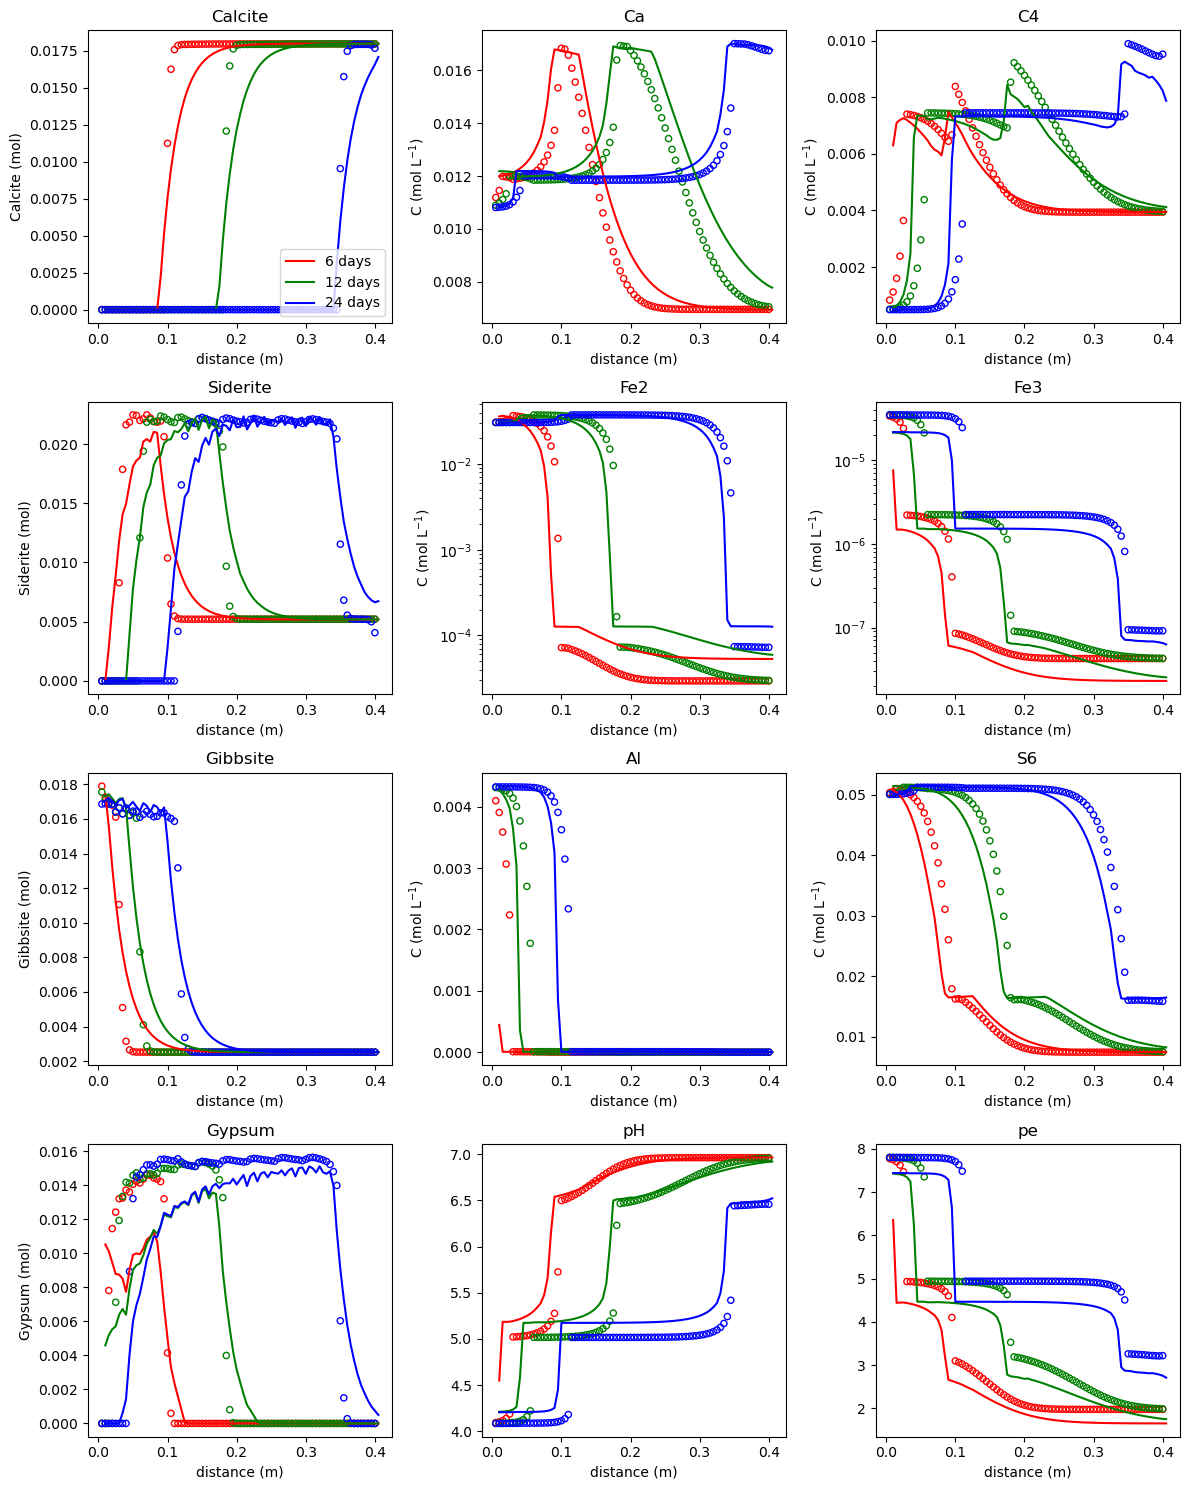

In [39]:
# create summary plots to compare mf6rtm results to pht3d
wd = os.path.join(f'{prefix}', f'pht3d')
# dx = 0.01
simdf = pd.read_csv(os.path.join(wd, 'out.dat'), sep = '\t', skipinitialspace=True, index_col=[0])
simdf.drop(simdf.columns[len(simdf.columns)-1], axis=1, inplace=True)

simdf.loc[:, 'x'] = simdf['cell'] * delr

simapi = pd.read_csv(os.path.join(model.wd,'sout.csv'), sep = ',', skipinitialspace=True, index_col=[0])
simapi.loc[:, 'x'] = (simapi['cell'] + 1)*delr

#offset index of simapi by tstep
simapi.index = simapi.index + tstep

simapi

# get all ucn files in wd
ucn_files = [f for f in os.listdir(wd) if f.lower().endswith('.ucn')]
ucn_files

# get file that ends in py
pht3dpy = [f for f in os.listdir(wd) if f.endswith('py')]

#read pht3dpy file
ucndic = {}
pht3dpy = os.path.join(wd, pht3dpy[0])
with open(pht3dpy, 'r') as f:
    # print(f.read())
    for l in f:
        n =re.findall(r'\d+', l.split()[-1])[-1]
        ucndic[l.split()[0].replace('_', "")] = f"PHT3D{n}.UCN"
        
for k,v in ucndic.items():
    ucn = flopy.utils.HeadFile(os.path.join(wd, v),text=f"concentration")
    results = ucn.get_alldata()
    ucndic[k] = results
timespht3d = ucn.get_times()
    
for var in simapi.columns:
    closest_match = find_closest_match(var, ucndic)
    if closest_match:
        ucndic[var] = ucndic.pop(closest_match)

simdf = pd.read_csv(os.path.join(wd, 'out.dat'), sep = '\t', skipinitialspace=True, index_col=[0])
simdf.drop(simdf.columns[len(simdf.columns)-1], axis=1, inplace=True)

simdf.loc[:, 'x'] = simdf['cell'] * delr
# simdf.drop(columns = 'H', inplace = True)

simapi = pd.read_csv(os.path.join(model.wd,'sout.csv'), sep = ',', skipinitialspace=True, index_col=[0])
simapi.loc[:, 'x'] = (simapi['cell'] + 1)*delr
simapi.index = [round(i, 2) for i in simapi.index]
simapi = simapi[simdf.columns]

vars_to_plot = ['Calcite', 'Ca',  'C4', 'Siderite', 'Fe2', 'Fe3', 'Gibbsite',  'Al', 'S6','Gypsum',  'pH', 'pe']
plot_cols = 3
plot_rows = calc_rows_from_ncol(vars_to_plot, ncols=plot_cols)
fig, axs = plt.subplots(plot_rows,plot_cols, figsize = (12, 15))

colors = ['r', 'g', 'b']
times_to_plot = [6., 12., 24.]
for var, ax in zip(vars_to_plot, axs.flatten()):

    for t in times_to_plot:
        ax.plot(simapi.x.unique(), simapi.loc[t, var].values,label = f'{round(t)} days', c = colors[times_to_plot.index(t)])
        ax.scatter(simdf.x.unique(), simdf.loc[t, var], edgecolors=colors[times_to_plot.index(t)], 
                   facecolors='none', s=20)
        if var.startswith('Fe'):
            ax.set_yscale('log')
    ax.set_xlabel('distance (m)')
    if var not in ['pH', 'pe'] and len(var) < 4:
        ax.set_ylabel('C (mol L$^{-1}$)')
    elif len(var) > 3:
        ax.set_ylabel(f'{var} (mol)')
    ax.set_title(f'{var}')
    #add legend in only one subplot
    if var == vars_to_plot[0]:
        ax.legend(loc = 'lower right')

fig.tight_layout()
fig.savefig(os.path.join(f'{prefix}.png'))

